# DREAM Embed — Training Notebook

Notebook này chạy **toàn bộ training pipeline** từ đầu đến cuối:

```
0. Setup & cấu trúc thư mục
1. Config
2. Reproducibility (seed)
3. Backbone → pre-compute embeddings
4. Dataset & DataLoader
5. Model + Optimizer
6. Training loop (Trainer)
7. Resume từ checkpoint
8. Quick inference check sau khi train
```

> **Yêu cầu:** Đã có data Tatoeba split sẵn ở `data/Tatoeba_Train/` và `data/Tatoeba_Val/`  
> Xem cell `0c` để biết cách tổ chức thư mục.

---
## Cell 0a — Cài đặt dependencies

In [4]:
# Chạy 1 lần nếu chưa cài
# !pip install -e ".[dev]" --quiet

## Cell 0b — Thêm src/ vào Python path

Notebook nằm ở `notebooks/` (hoặc root), cần trỏ đúng tới `src/`.

In [5]:
import sys
from pathlib import Path

# Tự động tìm root của repo (thư mục chứa pyproject.toml)
def _find_repo_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / "pyproject.toml").exists():
            return parent
    return start

REPO_ROOT = _find_repo_root(Path.cwd())
SRC_PATH  = REPO_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

print(f"Repo root : {REPO_ROOT}")
print(f"src/ path : {SRC_PATH}")
print(f"sys.path  : {sys.path[:3]}")

Repo root : d:\_PythonProjects\DREAM-vi\DREAM-vi
src/ path : d:\_PythonProjects\DREAM-vi\DREAM-vi\src
sys.path  : ['d:\\_PythonProjects\\DREAM-vi\\DREAM-vi\\src', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\python311.zip', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\DLLs']


## Cell 0c — Cấu trúc thư mục cần có

```
dream-embed/
├── src/dream/          ← code của bạn
├── data/
│   ├── Tatoeba_Train/  ← *.tsv files (en-ar, en-de, en-es, en-fr, en-it, en-nl, en-tr)
│   └── Tatoeba_Val/    ← *.tsv files (cùng format)
├── checkpoints/        ← tự tạo khi train
├── configs/train.yaml
└── notebooks/          ← notebook này
```

**Format TSV** (không có header):
```
src_id  \t  src_text  \t  tgt_id  \t  tgt_text
```

---
## Cell 1 — Config

Tất cả hyperparameter ở một chỗ.  
Thay đổi ở đây rồi chạy lại — không cần sửa code.

In [6]:
from dataclasses import dataclass

# ── Model ─────────────────────────────────────────────────────────────────
BACKBONE      = "sentence-transformers/LaBSE"  # hoặc "xlm-roberta-large"
EMBEDDING_DIM = 768   # LaBSE/mBERT = 768 | XLM-R-large = 1024

# ── Data ──────────────────────────────────────────────────────────────────
TRAIN_DIR    = str(REPO_ROOT / "data" / "Tatoeba_Train")
VAL_DIR      = str(REPO_ROOT / "data" / "Tatoeba_Val")
BATCH_SIZE   = 512
ENCODE_BATCH = 64    # batch size cho backbone.encode() khi pre-compute
NUM_WORKERS  = 4     # set = 0 nếu debug trên Windows

# ── Training ──────────────────────────────────────────────────────────────
EPOCHS        = 100
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 0.0  # paper dùng plain Adam, không WD
PATIENCE      = 15   # early stopping
MIN_DELTA     = 1e-4

# ── Checkpointing ─────────────────────────────────────────────────────────
CHECKPOINT_DIR = str(REPO_ROOT / "checkpoints")
SAVE_EVERY     = 5   # lưu rolling checkpoint mỗi N epoch
KEEP_LAST_K    = 3   # giữ K checkpoint gần nhất

# ── Hardware ──────────────────────────────────────────────────────────────
DEVICE = "cuda"   # "cuda" | "cpu" | "mps"
SEED   = 42

print("Config loaded.")
print(f"  backbone      = {BACKBONE}")
print(f"  embedding_dim = {EMBEDDING_DIM}")
print(f"  train_dir     = {TRAIN_DIR}")
print(f"  batch_size    = {BATCH_SIZE}")
print(f"  epochs        = {EPOCHS}")
print(f"  device        = {DEVICE}")

Config loaded.
  backbone      = sentence-transformers/LaBSE
  embedding_dim = 768
  train_dir     = d:\_PythonProjects\DREAM-vi\DREAM-vi\data\Tatoeba_Train
  batch_size    = 512
  epochs        = 100
  device        = cuda


---
## Cell 2 — Reproducibility

In [7]:
import random
import numpy as np
import torch

def set_seed(seed: int) -> None:
    """Seed tất cả RNG để kết quả reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)

# Kiểm tra device thực sự available
import torch
device = torch.device(DEVICE if (DEVICE != "cuda" or torch.cuda.is_available()) else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
  GPU: NVIDIA GeForce RTX 4080 SUPER
  VRAM: 17.2 GB


---
## Cell 3 — Load backbone và pre-compute embeddings

**Quan trọng:** Backbone (LaBSE) chỉ chạy **1 lần** để pre-compute tất cả embeddings.  
Sau đó backbone được giải phóng khỏi GPU — training chỉ dùng MLP heads nhỏ.

Đây là lý do training loop rất nhanh.

In [8]:
import logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%H:%M:%S",
)

from sentence_transformers import SentenceTransformer

print(f"Loading backbone: {BACKBONE} ...")
backbone = SentenceTransformer(BACKBONE)

# Kiểm tra embedding dim khớp với config
actual_dim = backbone.get_sentence_embedding_dimension()
assert actual_dim == EMBEDDING_DIM, (
    f"Config EMBEDDING_DIM={EMBEDDING_DIM} nhưng backbone output dim={actual_dim}.\n"
    f"Hãy sửa EMBEDDING_DIM = {actual_dim} trong Cell 1."
)
print(f"  embedding_dim = {actual_dim}  ✓")

23:09:30 | INFO | PyTorch version 2.5.1+cu124 available.
23:09:31 | INFO | Use pytorch device_name: cuda
23:09:31 | INFO | Load pretrained SentenceTransformer: sentence-transformers/LaBSE


Loading backbone: sentence-transformers/LaBSE ...
  embedding_dim = 768  ✓


---
## Cell 4 — Dataset

`MultilingualDataset` sẽ:
1. Đọc tất cả `*.tsv` trong `TRAIN_DIR`
2. Gọi `backbone.encode()` cho mỗi language pair (progress bar hiện ra)
3. Lưu embedding vào RAM (CPU tensor)
4. Backbone sẽ được giải phóng sau cell này

In [9]:
from dream.dataset import MultilingualDataset, free_backbone

print("=" * 60)
print("Pre-computing TRAIN embeddings ...")
print("=" * 60)
train_ds = MultilingualDataset(
    data_dir=TRAIN_DIR,
    backbone=backbone,
    encode_batch=ENCODE_BATCH,
)

print()
print("=" * 60)
print("Pre-computing VAL embeddings ...")
print("=" * 60)
val_ds = MultilingualDataset(
    data_dir=VAL_DIR,
    backbone=backbone,
    encode_batch=ENCODE_BATCH,
)

print()
print(f"Train samples : {len(train_ds):,}")
print(f"Val samples   : {len(val_ds):,}")
print(f"Language pairs: {len(train_ds._datasets)}")
for i, ds in enumerate(train_ds._datasets):
    print(f"  [{i}] {ds.tsv_path.name}  →  {len(ds):,} pairs")

23:09:39 | INFO | Loading 7 language pairs from d:\_PythonProjects\DREAM-vi\DREAM-vi\data\Tatoeba_Train …
23:09:39 | INFO |   Sentence pairs in English-Arabic - 2026-03-12.tsv: 43,408 pairs (src_lang=0, tgt_lang=1)


Pre-computing TRAIN embeddings ...


Batches:   0%|          | 0/618 [00:00<?, ?it/s]

Batches:   0%|          | 0/654 [00:00<?, ?it/s]

23:09:58 | INFO |   Sentence pairs in English-Dutch - 2026-03-12.tsv: 151,886 pairs (src_lang=0, tgt_lang=6)


...

23:26:57 | INFO |   Sentence pairs in English-Turkish - 2026-03-12.tsv: 71,500 pairs (src_lang=0, tgt_lang=7)


Batches:   0%|          | 0/1110 [00:00<?, ?it/s]

Batches:   0%|          | 0/1105 [00:00<?, ?it/s]

23:27:26 | INFO | Total samples: 292,062



Train samples : 2,628,566
Val samples   : 292,062
Language pairs: 7
  [0] Sentence pairs in English-Arabic - 2026-03-12.tsv  →  43,408 pairs
  [1] Sentence pairs in English-Dutch - 2026-03-12.tsv  →  151,886 pairs
  [2] Sentence pairs in English-French - 2026-03-12.tsv  →  387,027 pairs
  [3] Sentence pairs in English-German - 2026-03-12.tsv  →  517,115 pairs
  [4] Sentence pairs in English-Italian - 2026-03-12.tsv  →  633,796 pairs
  [5] Sentence pairs in English-Spanish - 2026-03-12.tsv  →  251,833 pairs
  [6] Sentence pairs in English-Turkish - 2026-03-12.tsv  →  643,501 pairs


In [10]:
# Giải phóng backbone khỏi GPU — không cần nữa
# Backbone đã xong việc; training chỉ dùng MLP heads
print("Releasing backbone from GPU memory ...")
free_backbone(backbone)
del backbone

if torch.cuda.is_available():
    print(f"  VRAM free after release: {torch.cuda.memory_allocated() / 1e6:.1f} MB used")
print("  Done.")

Releasing backbone from GPU memory ...
  VRAM free after release: 8.5 MB used
  Done.


---
## Cell 5 — DataLoader

In [11]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,       # shuffling được làm bởi dataset.shuffle() mỗi epoch
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=max(NUM_WORKERS // 2, 1),
    pin_memory=(device.type == "cuda"),
)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")

# Sanity check: xem 1 batch
sample_batch = next(iter(train_loader))
e_src, e_tgt, rand_src, rand_tgt, src_lid, tgt_lid = sample_batch
print()
print("Sample batch shapes:")
print(f"  e_src    : {e_src.shape}    dtype={e_src.dtype}")
print(f"  e_tgt    : {e_tgt.shape}")
print(f"  rand_src : {rand_src.shape}")
print(f"  rand_tgt : {rand_tgt.shape}")
print(f"  src_lid  : {src_lid.shape}  values={src_lid.unique().tolist()}")
print(f"  tgt_lid  : {tgt_lid.shape}  values={tgt_lid.unique().tolist()}")

Train batches : 5134
Val batches   : 571

Sample batch shapes:
  e_src    : torch.Size([512, 768])    dtype=torch.float32
  e_tgt    : torch.Size([512, 768])
  rand_src : torch.Size([512, 768])
  rand_tgt : torch.Size([512, 768])
  src_lid  : torch.Size([512])  values=[0]
  tgt_lid  : torch.Size([512])  values=[1, 2, 3, 4, 5, 6, 7]


---
## Cell 6 — Model

`num_languages` được tính tự động từ số language pairs trong training set + 1 (English).  
Giá trị này được lưu vào checkpoint để `DREAMPipeline` tự đọc lại khi inference.

In [12]:
from dream.model import DREAMModel

# num_languages = số target languages + 1 (English)
NUM_LANGUAGES = len(train_ds._datasets) + 1

model = DREAMModel(
    embedding_dim=EMBEDDING_DIM,
    num_languages=NUM_LANGUAGES,
)

# Đếm số trainable parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print()
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"  (backbone LaBSE has ~470M params — NOT counted here)")

DREAMModel(
  embedding_dim=768, num_languages=8
  (meaning_encoder): Linear(in_features=768, out_features=768, bias=True)
  (language_encoder): Linear(in_features=768, out_features=768, bias=True)
  (language_identifier): Linear(in_features=768, out_features=8, bias=True)
)

Total parameters    : 1,187,336
Trainable parameters: 1,187,336
  (backbone LaBSE has ~470M params — NOT counted here)


---
## Cell 7 — Loss (kiểm tra trước khi train)

Chạy 1 forward pass thủ công để chắc chắn tất cả shapes và loss functions đúng.

In [13]:
from dream.loss import compute_loss

model_test = model.to(device)
model_test.train()

# Lấy 1 batch
e_src, e_tgt, rand_src, rand_tgt, src_lid, tgt_lid = [
    t.to(device) for t in next(iter(train_loader))
]

# Forward pass
em_src,      el_src,      logits_src      = model_test(e_src)
em_tgt,      el_tgt,      logits_tgt      = model_test(e_tgt)
em_rand_src, el_rand_src, _               = model_test(rand_src)
em_rand_tgt, el_rand_tgt, _               = model_test(rand_tgt)

lc = compute_loss(
    e_src, e_tgt,
    em_src, em_tgt, em_rand_src, em_rand_tgt,
    el_src, el_tgt, el_rand_src, el_rand_tgt,
    logits_src, logits_tgt, src_lid, tgt_lid,
)

print("Forward pass OK.")
print(f"  L_total          = {lc.total.item():.4f}")
print(f"  L_reconstruction = {lc.reconstruction.item():.4f}")
print(f"  L_meaning        = {lc.meaning.item():.4f}")
print(f"  L_language       = {lc.language.item():.4f}")

# Kiểm tra backward
lc.total.backward()
assert model_test.meaning_encoder.weight.grad is not None
print()
print("Backward pass OK.  Gradients computed.")

# Reset grad
model_test.zero_grad()

Forward pass OK.
  L_total          = 6.1870
  L_reconstruction = 0.0063
  L_meaning        = 1.2972
  L_language       = 4.8836

Backward pass OK.  Gradients computed.


---
## Cell 8 — Trainer config

> **Lưu ý:** `TrainerConfig` không có field `seed` (seed được set ở Cell 2).  
> Chỉ pass các fields mà dataclass định nghĩa.

In [14]:
from dream.trainer import Trainer, TrainerConfig

trainer_cfg = TrainerConfig(
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    patience=PATIENCE,
    min_delta=MIN_DELTA,
    checkpoint_dir=CHECKPOINT_DIR,
    save_every=SAVE_EVERY,
    keep_last_k=KEEP_LAST_K,
    device=str(device),
)

print(trainer_cfg)

TrainerConfig(epochs=100, learning_rate=0.0001, weight_decay=0.0, patience=15, min_delta=0.0001, checkpoint_dir='d:\\_PythonProjects\\DREAM-vi\\DREAM-vi\\checkpoints', save_every=5, keep_last_k=3, device='cuda')


---
## Cell 9 — Training

**Trainer tự động:**
- Gọi `train_ds.shuffle()` đầu mỗi epoch (regenerate random negatives)
- Lưu `dream_best.pt` mỗi khi val loss cải thiện
- Lưu `dream_epoch_XXXX.pt` mỗi `SAVE_EVERY` epochs
- Dừng khi val loss không cải thiện sau `PATIENCE` epochs

In [15]:
# trainer = Trainer(
#     model=model,
#     train_loader=train_loader,
#     val_loader=val_loader,
#     cfg=trainer_cfg,
# )

# trainer.fit()

---
## Cell 10 — Resume từ checkpoint (nếu cần)

Dùng khi:
- Colab/Kaggle bị timeout
- Muốn tiếp tục train thêm từ epoch đã lưu

In [16]:
# ── Chạy cell này để resume, bỏ qua nếu train từ đầu ──

RESUME_FROM = str(REPO_ROOT / "checkpoints" / "dream_epoch_0100.pt")  # ← sửa path

# Tạo lại model và trainer sạch
model_resumed = DREAMModel(embedding_dim=EMBEDDING_DIM, num_languages=NUM_LANGUAGES)

trainer_resumed = Trainer(
    model=model_resumed,
    train_loader=train_loader,
    val_loader=val_loader,
    cfg=trainer_cfg,
)

trainer_resumed.resume(RESUME_FROM)
# trainer_resumed.fit()   # ← bỏ comment để chạy

d:\_PythonProjects\DREAM-vi\DREAM-vi\src\dream\trainer.py:184: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(checkpoint_path, map_location=self.device)
23:

---
## Cell 11 — Kiểm tra checkpoint đã lưu

In [17]:
import os

ckpt_dir = Path(CHECKPOINT_DIR)
checkpoints = sorted(ckpt_dir.glob("dream_*.pt"))

if not checkpoints:
    print("Chưa có checkpoint nào — hãy chạy training ở Cell 9 trước.")
else:
    print(f"Checkpoints trong {ckpt_dir}:")
    for ckpt in checkpoints:
        size_mb = ckpt.stat().st_size / 1e6
        meta    = torch.load(ckpt, map_location="cpu", weights_only=False)
        print(
            f"  {ckpt.name:<35}"
            f"  epoch={meta['epoch']:3d}"
            f"  best_val={meta['best_val_loss']:.4f}"
            f"  size={size_mb:.1f} MB"
        )

Checkpoints trong d:\_PythonProjects\DREAM-vi\DREAM-vi\checkpoints:
  dream_best.pt                        epoch= 89  best_val=1.0936  size=14.3 MB
  dream_epoch_0090.pt                  epoch= 90  best_val=1.0936  size=14.3 MB
  dream_epoch_0095.pt                  epoch= 95  best_val=1.0936  size=14.3 MB
  dream_epoch_0100.pt                  epoch=100  best_val=1.0936  size=14.3 MB


---
## Cell 12 — Quick inference check

Load `dream_best.pt` qua `DREAMPipeline` và chạy vài ví dụ cross-lingual.

In [18]:
from dream.pipeline import DREAMPipeline

BEST_CKPT = str(REPO_ROOT / "checkpoints" / "dream_best.pt")

if not Path(BEST_CKPT).exists():
    print(f"Checkpoint chưa có: {BEST_CKPT}")
    print("Hãy chạy training ở Cell 9 trước.")
else:
    pipe = DREAMPipeline.from_pretrained(
        checkpoint_path=BEST_CKPT,
        backbone_name=BACKBONE,
        device=str(device),
    )
    print(f"Pipeline loaded: {pipe}")

23:29:46 | INFO | Load pretrained SentenceTransformer: sentence-transformers/LaBSE


Pipeline loaded: DREAMPipeline(backbone='sentence-transformers/LaBSE', dream=DREAMModel(
  embedding_dim=768, num_languages=8
  (meaning_encoder): Linear(in_features=768, out_features=768, bias=True)
  (language_encoder): Linear(in_features=768, out_features=768, bias=True)
  (language_identifier): Linear(in_features=768, out_features=8, bias=True)
), device=cuda)


In [19]:
# ── Ví dụ 1: cross-lingual pairs (cùng nghĩa, khác ngôn ngữ) ──
test_pairs = [
    ("The cat sat on the mat.",        "Le chat était assis sur le tapis."),   # en-fr
    ("I love artificial intelligence.", "Tôi yêu trí tuệ nhân tạo."),          # en-vi
    ("The weather is beautiful today.", "Das Wetter ist heute schön."),         # en-de
    ("She reads books every night.",    "Ella lee libros todas las noches."),    # en-es
    # Cùng ngôn ngữ, khác nghĩa → similarity phải thấp
    ("The cat sat on the mat.",         "The stock market crashed today."),
]

print(f"{'Sentence A':<45} {'Sentence B':<45} {'Score':>7}")
print("-" * 100)
for a, b in test_pairs:
    score = pipe.similarity(a, b)
    flag  = "✓" if score > 0.7 else ("~" if score > 0.4 else "✗")
    print(f"{a[:43]:<45} {b[:43]:<45} {score:>6.4f} {flag}")

Sentence A                                    Sentence B                                      Score
----------------------------------------------------------------------------------------------------
The cat sat on the mat.                       Le chat était assis sur le tapis.             0.9541 ✓
I love artificial intelligence.               Tôi yêu trí tuệ nhân tạo.                     0.8717 ✓
The weather is beautiful today.               Das Wetter ist heute schön.                   0.9766 ✓
She reads books every night.                  Ella lee libros todas las noches.             0.9838 ✓
The cat sat on the mat.                       The stock market crashed today.               0.1411 ✗


In [20]:
# ── Ví dụ 2: similarity matrix ──
sentences = [
    "The cat sat on the mat.",
    "Le chat était assis sur le tapis.",
    "El gato estaba sentado en la alfombra.",
    "Die Katze saß auf der Matte.",
    "The stock market crashed today.",  # khác nghĩa hoàn toàn
]

matrix = pipe.similarity_matrix(sentences)

# In ra dạng bảng
labels = [s[:30] + "…" if len(s) > 30 else s for s in sentences]
col_w  = 10

print(f"{'':32s}", end="")
for lbl in labels:
    print(f"{lbl[:col_w]:>{col_w}s}", end="  ")
print()
print("-" * (32 + (col_w + 2) * len(labels)))

for i, row_lbl in enumerate(labels):
    print(f"{row_lbl:<32s}", end="")
    for j in range(len(labels)):
        val = matrix[i, j]
        print(f"{val:>{col_w}.4f}", end="  ")
    print()

print()
print("Rows 0-3 (same meaning, different language) → high similarity")
print("Row  4   (different meaning)                 → low similarity")

                                The cat sa  Le chat ét  El gato es  Die Katze   The stock   
--------------------------------------------------------------------------------------------
The cat sat on the mat.             1.0000      0.9541      0.9301      0.9540      0.1411  
Le chat était assis sur le tap…     0.9541      1.0000      0.9462      0.9536      0.1039  
El gato estaba sentado en la a…     0.9301      0.9462      1.0000      0.9177      0.1289  
Die Katze saß auf der Matte.        0.9540      0.9536      0.9177      1.0000      0.1441  
The stock market crashed today…     0.1411      0.1039      0.1289      0.1441      1.0000  

Rows 0-3 (same meaning, different language) → high similarity
Row  4   (different meaning)                 → low similarity


In [21]:
# ── Ví dụ 3: batch encode ──
import numpy as np

batch = [
    "Hello world",
    "Bonjour le monde",
    "Hola mundo",
    "Ciao mondo",
]

embeddings = pipe.encode(batch)  # (4, 768)

print(f"Output shape: {embeddings.shape}")
print(f"dtype       : {embeddings.dtype}")

# L2 norms phải = 1.0 (normalised)
norms = np.linalg.norm(embeddings, axis=1)
print(f"L2 norms    : {norms}  (phải ≈ 1.0)")

Output shape: (4, 768)


dtype       : float32
L2 norms    : [1.         0.99999994 1.         0.99999994]  (phải ≈ 1.0)


---
## Cell 13 — Visualise loss curves (nếu đã log)

Nếu bạn đã uncomment WandB trong `trainer.py`, dùng `wandb` dashboard.  
Cell này vẽ loss từ checkpoint history nếu bạn đã lưu log riêng.

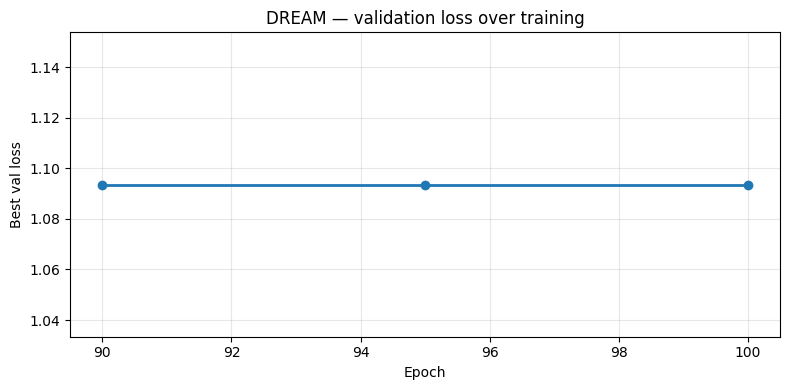

In [22]:
# Đọc tất cả epoch checkpoints và plot loss
import matplotlib.pyplot as plt

ckpt_dir  = Path(CHECKPOINT_DIR)
epoch_ckpts = sorted(ckpt_dir.glob("dream_epoch_*.pt"))

if not epoch_ckpts:
    print("Không có epoch checkpoint để plot. Cần thêm logging vào Trainer để plot loss.")
    print("Gợi ý: uncomment WandB trong trainer.py để có đầy đủ loss curves.")
else:
    epochs_seen, val_losses = [], []
    for ckpt in epoch_ckpts:
        meta = torch.load(ckpt, map_location="cpu", weights_only=False)
        epochs_seen.append(meta["epoch"])
        val_losses.append(meta["best_val_loss"])

    plt.figure(figsize=(8, 4))
    plt.plot(epochs_seen, val_losses, marker="o", linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Best val loss")
    plt.title("DREAM — validation loss over training")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

---
## Cell 14 — Bước tiếp theo

Sau khi training xong:

```bash
# 1. Evaluate trên STS2017 (tái hiện Table 4 của paper)
python scripts/evaluate.py --checkpoint checkpoints/dream_best.pt

# 2. Chạy Gradio demo local
DREAM_CHECKPOINT=checkpoints/dream_best.pt python api/demo.py

# 3. Chạy FastAPI
DREAM_CHECKPOINT=checkpoints/dream_best.pt uvicorn api.app:app --reload
# Swagger UI → http://localhost:8000/docs

# 4. Docker
docker build -t dream-embed .
docker run -p 7860:7860 -v $(pwd)/checkpoints:/app/checkpoints dream-embed
```

**Deploy lên HuggingFace Spaces:**
1. Tạo Space mới (Gradio SDK)
2. Push repo này lên
3. Upload `checkpoints/dream_best.pt` vào Space files
4. Set Secret: `DREAM_CHECKPOINT = checkpoints/dream_best.pt`